In [1]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv') 


df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.shape


(8807, 12)

In [3]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isna().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
import pandas as pd

# Load the extracted CSV into the correct variable
netflix_title = pd.read_csv('netflix_titles.csv')  # Variable name must match

# 1. Remove duplicate records (based on title & type)
netflix_title.drop_duplicates(subset=['title', 'type'], inplace=True)

# 2. Handle missing values
netflix_title['director'].fillna('Not Available', inplace=True)
netflix_title['cast'].fillna('Not Available', inplace=True)
netflix_title['country'].fillna('Not Available', inplace=True)
netflix_title['rating'].fillna('Not Rated', inplace=True)
netflix_title['duration'].fillna('Not Available', inplace=True)

# 3. Convert date_added to proper date format
netflix_title['date_added'] = pd.to_datetime(netflix_title['date_added'], errors='coerce')

# 4. Drop rows where date_added is still null (very few records)
netflix_title.dropna(subset=['date_added'], inplace=True)

# 5. Reset index after cleaning
netflix_title.reset_index(drop=True, inplace=True)

# 6. Save cleaned data to new CSV
netflix_title.to_csv('netflix_clean.csv', index=False)

# Final verification
print("Cleaned Dataset Shape:", netflix_title.shape)
print("\nMissing Values After Cleaning:\n", netflix_title.isna().sum())
print("\nClean CSV file 'netflix_clean.csv' created successfully")


Cleaned Dataset Shape: (8709, 12)

Missing Values After Cleaning:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Clean CSV file 'netflix_clean.csv' created successfully


C:\Users\Win10\AppData\Local\Temp\ipykernel_19364\3655018311.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  netflix_title['director'].fillna('Not Available', inplace=True)
C:\Users\Win10\AppData\Local\Temp\ipykernel_19364\3655018311.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

In [7]:
import pandas as pd

# Load the cleaned CSV
netflix = pd.read_csv('netflix_clean.csv')

# 1. Strip leading/trailing spaces in key columns
cols_to_strip = ['title', 'type', 'director', 'country', 'rating']
for col in cols_to_strip:
    netflix[col] = netflix[col].astype(str).str.strip()

# 2. Trim genre names in 'listed_in' column
netflix['listed_in'] = netflix['listed_in'].astype(str).apply(lambda x: ', '.join([i.strip() for i in x.split(',')]))

# 3. Standardize duration column
# Convert numeric duration for movies, keep seasons as is
def standardize_duration(val):
    val = str(val).strip()
    if 'min' in val:
        return val.replace(' min','')
    elif 'Season' in val:
        return val
    else:
        return val

netflix['duration'] = netflix['duration'].apply(standardize_duration)

# 4. Optional: Convert text columns to uppercase for SQL consistency
text_cols = ['title','type','director','country','rating']
for col in text_cols:
    netflix[col] = netflix[col].str.upper()

# 5. Save the improved clean CSV
netflix.to_csv('netflix_clean_final.csv', index=False)

# Verification
print("Final Clean CSV saved as 'netflix_clean_final.csv'")
print("Shape:", netflix.shape)
print("\nSample Data:\n", netflix.head())


Final Clean CSV saved as 'netflix_clean_final.csv'
Shape: (8709, 12)

Sample Data:
   show_id     type                  title         director  \
0      s1    MOVIE   DICK JOHNSON IS DEAD  KIRSTEN JOHNSON   
1      s2  TV SHOW          BLOOD & WATER    NOT AVAILABLE   
2      s3  TV SHOW              GANGLANDS  JULIEN LECLERCQ   
3      s4  TV SHOW  JAILBIRDS NEW ORLEANS    NOT AVAILABLE   
4      s5  TV SHOW           KOTA FACTORY    NOT AVAILABLE   

                                                cast        country  \
0                                      Not Available  UNITED STATES   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   SOUTH AFRICA   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...  NOT AVAILABLE   
3                                      Not Available  NOT AVAILABLE   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          INDIA   

   date_added  release_year rating   duration  \
0  2021-09-25          2020  PG-13         90   
1  2021-09-24     

In [17]:

import pandas as pd


netflix = pd.read_csv('netflix_clean_final.csv')

netflix.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,MOVIE,DICK JOHNSON IS DEAD,KIRSTEN JOHNSON,Not Available,UNITED STATES,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV SHOW,BLOOD & WATER,NOT AVAILABLE,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",SOUTH AFRICA,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV SHOW,GANGLANDS,JULIEN LECLERCQ,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NOT AVAILABLE,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV SHOW,JAILBIRDS NEW ORLEANS,NOT AVAILABLE,Not Available,NOT AVAILABLE,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV SHOW,KOTA FACTORY,NOT AVAILABLE,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",INDIA,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
import pandas as pd


netflix = pd.read_csv('netflix_clean_final.csv')


# 1️⃣ Count of Movies vs TV Shows
type_count = netflix['type'].value_counts()
print("1️⃣ Movies vs TV Shows:\n", type_count)


# 2️⃣ Number of titles released per year
year_count = netflix['release_year'].value_counts().sort_index()
print("\n2️⃣ Titles Released Per Year:\n", year_count)


# 3️⃣ Top 10 countries by number of titles
top_countries = netflix['country'].value_counts().head(10)
print("\n3️⃣ Top 10 Countries by Content:\n", top_countries)


# 4️⃣ Distribution of content ratings
rating_count = netflix['rating'].value_counts()
print("\n4️⃣ Rating Distribution:\n", rating_count)


# 5️⃣ Top 10 Genres
# Split 'listed_in' column into individual genres
genre_list = netflix['listed_in'].str.split(',').explode().str.strip()
top_genres = genre_list.value_counts().head(10)
print("\n5️⃣ Top 10 Genres:\n", top_genres)


1️⃣ Movies vs TV Shows:
 type
MOVIE      6131
TV SHOW    2578
Name: count, dtype: int64

2️⃣ Titles Released Per Year:
 release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1016
2018    1140
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

3️⃣ Top 10 Countries by Content:
 country
UNITED STATES     2778
INDIA              971
NOT AVAILABLE      827
UNITED KINGDOM     403
JAPAN              241
SOUTH KOREA        195
CANADA             173
SPAIN              141
FRANCE             122
MEXICO             110
Name: count, dtype: int64

4️⃣ Rating Distribution:
 rating
TV-MA        3183
TV-14        2133
TV-PG         838
R             799
PG-13         490
TV-Y7         330
TV-Y          300
PG            287
TV-G          212
NR             78
G              41
TV-Y7-FV        5
NOT RATED       4
NC-17           3
UR              3
66 MIN          1
74 MIN          1
84 MIN          1
Name: count, dtype: int64

5️

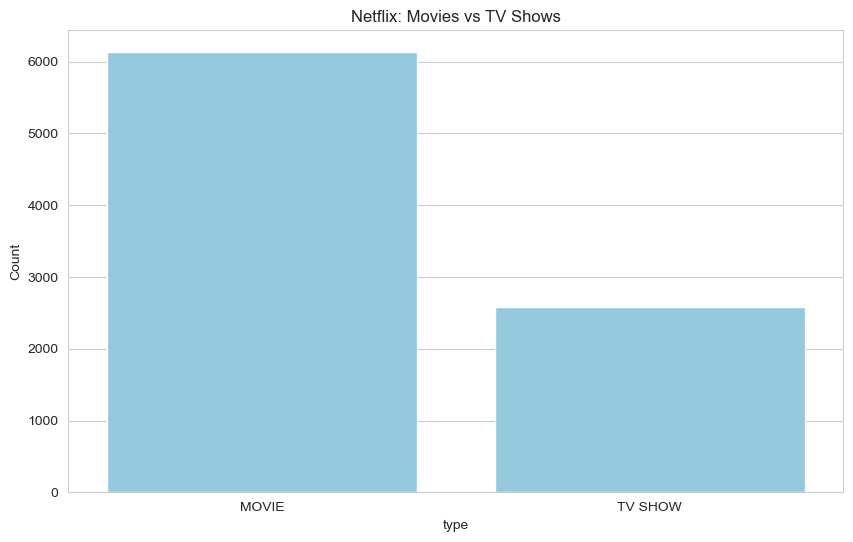

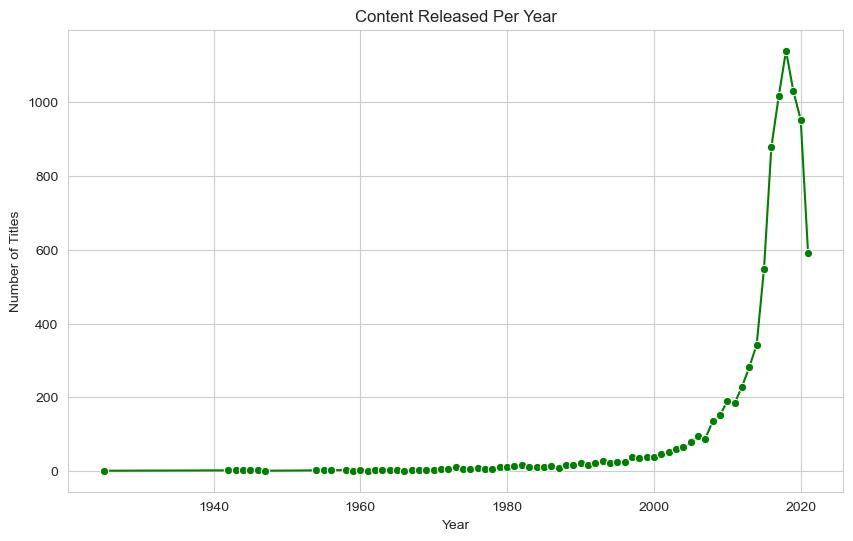

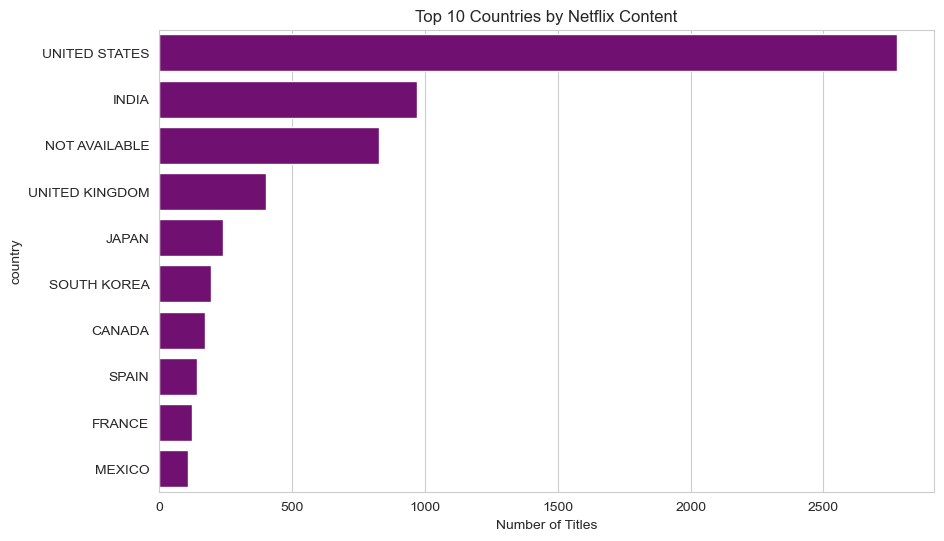

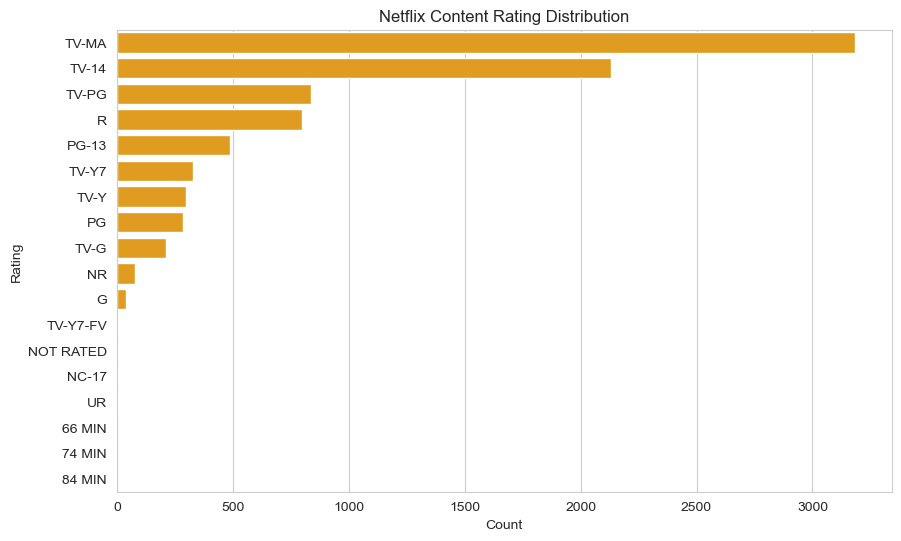

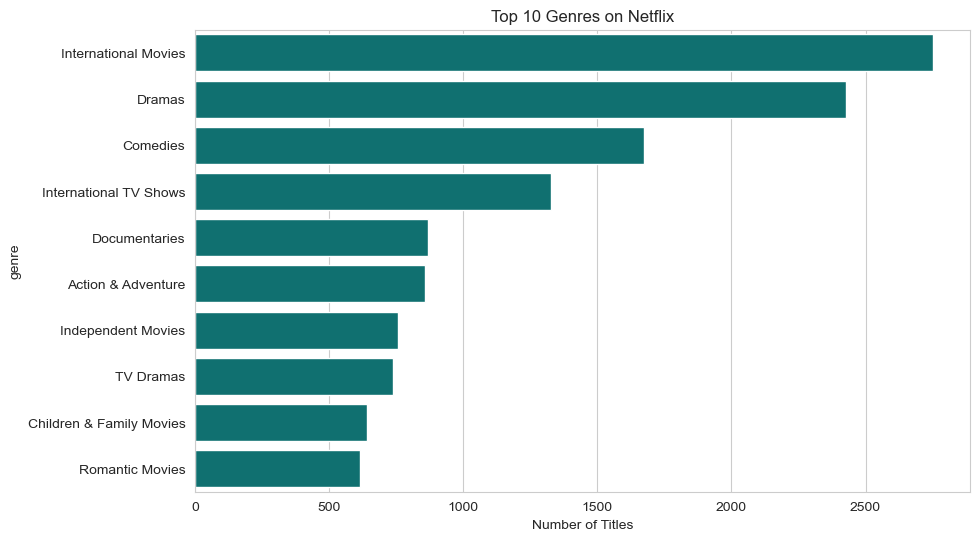

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final cleaned CSV
netflix = pd.read_csv('netflix_clean_final.csv')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# -------------------------------
# 1. Movies vs TV Shows
df_type = netflix['type'].value_counts().reset_index()
df_type.columns = ['type','count']
plt.figure()
sns.barplot(data=df_type, x='type', y='count', color='skyblue')
plt.title('Netflix: Movies vs TV Shows')
plt.ylabel('Count')
plt.show()

# -------------------------------
# 2. Titles Released Per Year
df_year = netflix['release_year'].value_counts().reset_index()
df_year.columns = ['release_year','count']
df_year = df_year.sort_values('release_year')
plt.figure()
sns.lineplot(data=df_year, x='release_year', y='count', marker='o', color='green')
plt.title('Content Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

# -------------------------------
# 3. Top 10 Countries by Content
df_country = netflix['country'].value_counts().head(10).reset_index()
df_country.columns = ['country','count']
plt.figure()
sns.barplot(data=df_country, x='count', y='country', color='purple')
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.show()

# -------------------------------
# 4. Rating Distribution
df_rating = netflix['rating'].value_counts().reset_index()
df_rating.columns = ['rating','count']
plt.figure()
sns.barplot(data=df_rating, x='count', y='rating', color='orange')
plt.title('Netflix Content Rating Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

# -------------------------------
# 5. Top 10 Genres
genre_list = netflix['listed_in'].str.split(',').explode().str.strip()
df_genre = genre_list.value_counts().head(10).reset_index()
df_genre.columns = ['genre','count']
plt.figure()
sns.barplot(data=df_genre, x='count', y='genre', color='teal')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.show()


In [10]:
import pyodbc

# Connection string using your server & database
conn_str = (
    r"DRIVER={ODBC Driver 17 for SQL Server};"
    r"SERVER=DESKTOP-3QNPVC1;"
    r"DATABASE=NetflixDB;"
    r"Trusted_Connection=yes;"
)

try:
    # Connect to SQL Server
    conn = pyodbc.connect(conn_str)
    cursor = conn.cursor()
    print(" Connected to NetflixDB successfully!")
except Exception as e:
    print(" Connection failed:", e)


 Connected to NetflixDB successfully!


In [11]:
cursor.execute("SELECT DB_NAME()")
print("Current Database:", cursor.fetchone()[0])


Current Database: NetflixDB


In [15]:
!pip install pyodbc pandas sqlalchemy


In [19]:
import pyodbc
import pandas as pd

# Load CSV
df = pd.read_csv("netflix_clean_final.csv")

# Connect to SQL Server
conn = pyodbc.connect(
    r"DRIVER={ODBC Driver 17 for SQL Server};"
    r"SERVER=DESKTOP-3QNPVC1;"
    r"DATABASE=NetflixDB;"
    r"Trusted_Connection=yes;"
)
cursor = conn.cursor()
print("Connected to NetflixDB successfully!")

# Insert data row by row
for index, row in df.iterrows():
    cursor.execute("""
        INSERT INTO NetflixShows
        (show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """,
    row['show_id'],
    row['type'],
    row['title'],
    row['director'],
    row['cast'],
    row['country'],
    row['date_added'],
    int(row['release_year']),
    row['rating'],
    row['duration'],
    row['listed_in'],
    row['description']
    )

conn.commit()
print("✅ All data inserted successfully!")

# Verify first 10 rows
cursor.execute("SELECT TOP 10 * FROM NetflixShows")
for r in cursor.fetchall():
    print(r)


Connected to NetflixDB successfully!
✅ All data inserted successfully!
('s1', 'MOVIE', 'DICK JOHNSON IS DEAD', 'KIRSTEN JOHNSON', 'Not Available', 'UNITED STATES', datetime.date(2021, 9, 25), 2020, 'PG-13', '90', 'Documentaries', 'As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.')
('s2', 'TV SHOW', 'BLOOD & WATER', 'NOT AVAILABLE', 'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng', 'SOUTH AFRICA', datetime.date(2021, 9, 24), 2021, 'TV-MA', '2 Seasons', 'International TV Shows, TV Dramas, TV Mysteries', 'After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was ab